In [2]:
import time
from datetime import date, timedelta
from pathlib import Path

import gridstatus
import pandas as pd

HUB        = "TH_NP15_GEN-APND"
N_DAYS     = 30
CACHE_FILE = Path("data/caiso_np15_da_30d.parquet")

In [3]:
def pull_30_days_da(hub: str, n_days: int) -> pd.DataFrame:
    """Pull n_days of CAISO DA hourly LMPs for a single hub.
    Loops day-by-day with retry; concatenates the result."""
    caiso = gridstatus.CAISO()
    end   = date.today() - timedelta(days=2)        # buffer for data availability
    start = end - timedelta(days=n_days - 1)
    print(f"Pulling {start} → {end} for {hub}")

    dfs = []
    cur = start
    while cur <= end:
        try:
            df_day = caiso.get_lmp(
                date=cur,
                market="DAY_AHEAD_HOURLY",
                locations=[hub],
            )
            dfs.append(df_day)
            print(f"  ✓ {cur}  ({len(df_day)} rows)")
        except Exception as e:
            print(f"  ✗ {cur}  {e!r}")
        cur += timedelta(days=1)
        time.sleep(0.4)         # be polite to the public endpoint

    return pd.concat(dfs, ignore_index=True)


if CACHE_FILE.exists():
    print(f"Loading from cache: {CACHE_FILE}")
    df = pd.read_parquet(CACHE_FILE)
else:
    df = pull_30_days_da(HUB, N_DAYS)
    CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE_FILE)
    print(f"Cached to {CACHE_FILE}")

print(f"\n{len(df):,} rows across {df['Time'].dt.date.nunique()} days")
df.head()

2026-05-12 09:37:20 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-12 09:37:20 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20260411T07:00-0000&enddatetime=20260412T07:00-0000


Pulling 2026-04-11 → 2026-05-10 for TH_NP15_GEN-APND


2026-05-12 09:37:24 - DEBUG - Found 1 files: ['20260411_20260412_PRC_LMP_DAM_20260511_16_37_24_v12.csv']
2026-05-12 09:37:24 - DEBUG - Parsing file: 20260411_20260412_PRC_LMP_DAM_20260511_16_37_24_v12.csv


  ✓ 2026-04-11  (24 rows)


2026-05-12 09:37:29 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-12 09:37:29 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20260412T07:00-0000&enddatetime=20260413T07:00-0000
2026-05-12 09:37:31 - DEBUG - Found 1 files: ['20260412_20260413_PRC_LMP_DAM_20260511_16_37_31_v12.csv']
2026-05-12 09:37:31 - DEBUG - Parsing file: 20260412_20260413_PRC_LMP_DAM_20260511_16_37_31_v12.csv


...

2026-05-12 09:41:09 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-12 09:41:09 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20260509T07:00-0000&enddatetime=20260510T07:00-0000
2026-05-12 09:41:12 - DEBUG - Found 1 files: ['20260509_20260510_PRC_LMP_DAM_20260511_16_41_12_v12.csv']
2026-05-12 09:41:12 - DEBUG - Parsing file: 20260509_20260510_PRC_LMP_DAM_20260511_16_41_12_v12.csv


  ✓ 2026-05-09  (24 rows)


2026-05-12 09:41:17 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-12 09:41:17 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20260510T07:00-0000&enddatetime=20260511T07:00-0000
2026-05-12 09:41:20 - DEBUG - Found 1 files: ['20260510_20260511_PRC_LMP_DAM_20260511_16_41_20_v12.csv']
2026-05-12 09:41:20 - DEBUG - Parsing file: 20260510_20260511_PRC_LMP_DAM_20260511_16_41_20_v12.csv


  ✓ 2026-05-10  (24 rows)
Cached to data/caiso_np15_da_30d.parquet

720 rows across 30 days


,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2026-04-11 00:00:00-07:00,2026-04-11 00:00:00-07:00,2026-04-11 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,26.06649,27.27729,-0.11425,-1.09655
1,2026-04-11 01:00:00-07:00,2026-04-11 01:00:00-07:00,2026-04-11 02:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,26.16715,27.27729,-0.07360,-1.03654
2,2026-04-11 02:00:00-07:00,2026-04-11 02:00:00-07:00,2026-04-11 03:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,24.75450,25.56248,-0.00276,-0.80522
3,2026-04-11 03:00:00-07:00,2026-04-11 03:00:00-07:00,2026-04-11 04:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,23.98025,24.64220,0.09457,-0.75652
4,2026-04-11 04:00:00-07:00,2026-04-11 04:00:00-07:00,2026-04-11 05:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,24.67927,25.40549,-0.02249,-0.70373


<Axes: xlabel='hour'>

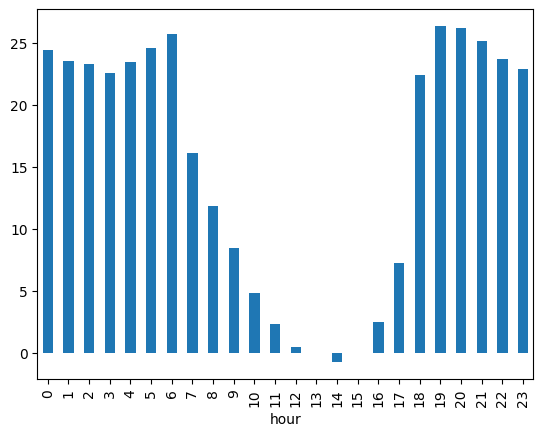

In [4]:
df["hour"] = df["Time"].dt.hour
hour_profile = df.groupby("hour")["LMP"].mean()
hour_profile.plot(kind="bar")     # or .plot() for a line

In [5]:
df["date"] = df["Time"].dt.date
shape_by_day = df.pivot(index="hour", columns="date", values="LMP")

In [6]:
peak_hours     = range(17, 22)
off_peak_hours = range(10, 15)

peak_avg     = df[df["hour"].isin(peak_hours)]["LMP"].mean()
off_peak_avg = df[df["hour"].isin(off_peak_hours)]["LMP"].mean()
spread       = peak_avg - off_peak_avg

print(f"Peak avg:     ${peak_avg:.2f}/MWh")
print(f"Off-peak avg: ${off_peak_avg:.2f}/MWh")
print(f"Spread:       ${spread:.2f}/MWh")

Peak avg:     $21.48/MWh
Off-peak avg: $1.36/MWh
Spread:       $20.12/MWh
